In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# import seaborn as sns

# Set style
# sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [2]:
# Load all training runs
shakespeare_dir = Path('data/shakespeare')
runs = []

for run_dir in sorted(shakespeare_dir.iterdir()):
    if run_dir.is_dir():
        config_path = run_dir / 'run_config.json'
        losses_path = run_dir / 'losses_shakespeare.json'
        accs_path = run_dir / 'accs_shakespeare.json'
        perps_path = run_dir / 'perplexities_shakespeare.json'
        
        if config_path.exists() and losses_path.exists():
            # Load config
            with open(config_path, 'r') as f:
                config = json.load(f)
            
            # Load losses (training loss at every step)
            with open(losses_path, 'r') as f:
                losses = json.load(f)
            
            # Load accuracies (validation accuracy at evaluation intervals)
            accs = None
            if accs_path.exists():
                with open(accs_path, 'r') as f:
                    accs = json.load(f)
            
            # Load perplexities (validation perplexity at evaluation intervals)
            perps = None
            if perps_path.exists():
                with open(perps_path, 'r') as f:
                    perps = json.load(f)
            
            runs.append({
                'name': run_dir.name,
                'D': config['D'],
                'M': config['M'],
                'config': config,
                'losses': losses,
                'accs': accs,
                'perplexities': perps
            })

print(f"Found {len(runs)} training runs:")
for run in runs:
    print(f"  {run['name']}: D={run['D']}, M={run['M']}")

Found 13 training runs:
  20260202_231239: D=16, M=16
  20260202_232806: D=32, M=16
  20260202_234939: D=32, M=32
  20260203_001217: D=64, M=32
  20260203_004751: D=64, M=64
  20260203_191105: D=64, M=64
  20260203_203522: D=128, M=64
  20260204_000631: D=128, M=128
  20260204_024305: D=256, M=128
  20260204_070704: D=256, M=256
  20260204_190507: D=256, M=256
  20260205_202744: D=256, M=256
  20260207_141334: D=256, M=256


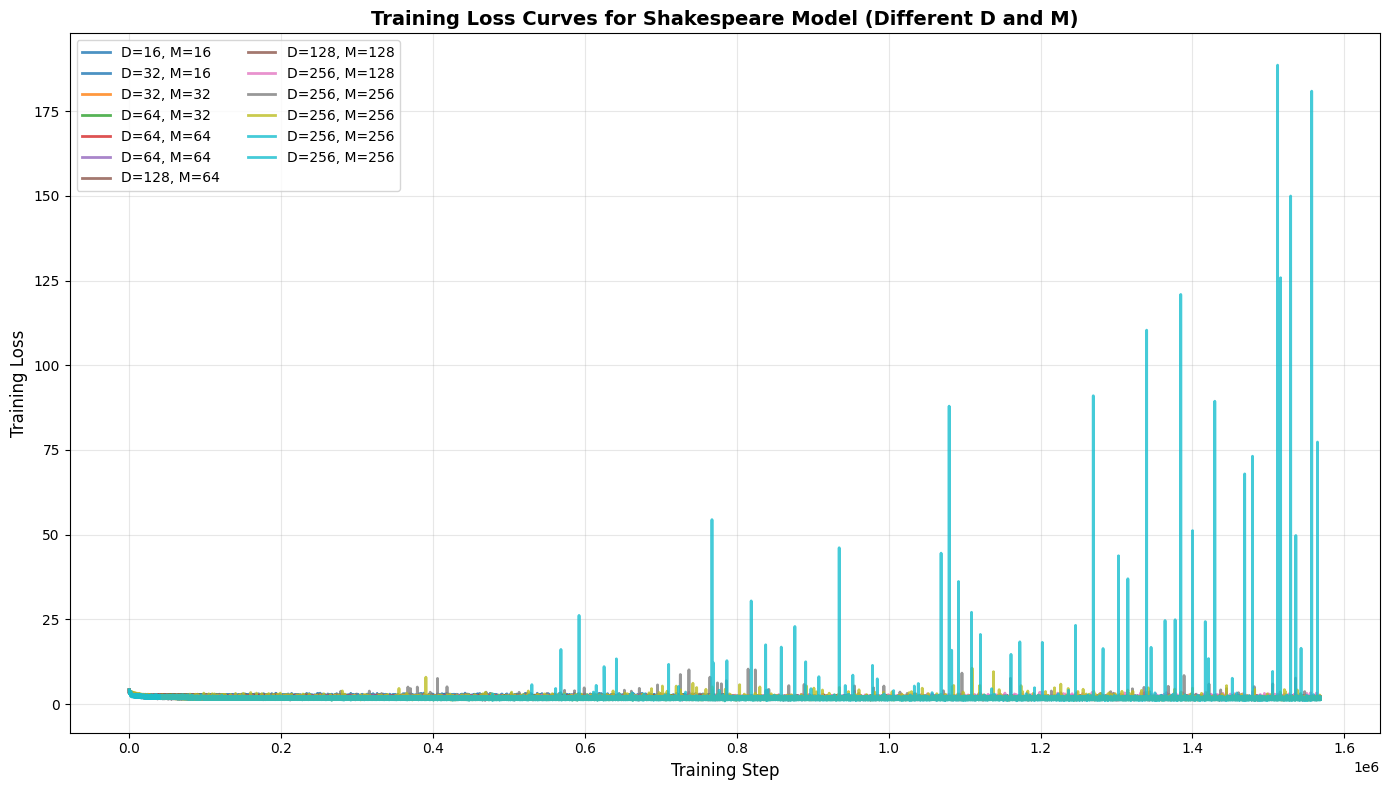

In [3]:
# Plot 1: Training Loss Curves
fig, ax = plt.subplots(figsize=(14, 8))

# Use a colormap for different runs
colors = plt.cm.tab10(np.linspace(0, 1, len(runs)))

for i, run in enumerate(runs):
    steps = np.array(run['losses']['step'])
    train_loss = np.array(run['losses']['loss'])
    
    label = f"D={run['D']}, M={run['M']}"
    ax.plot(steps, train_loss, label=label, color=colors[i], linewidth=2, alpha=0.8)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Curves for Shakespeare Model (Different D and M)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

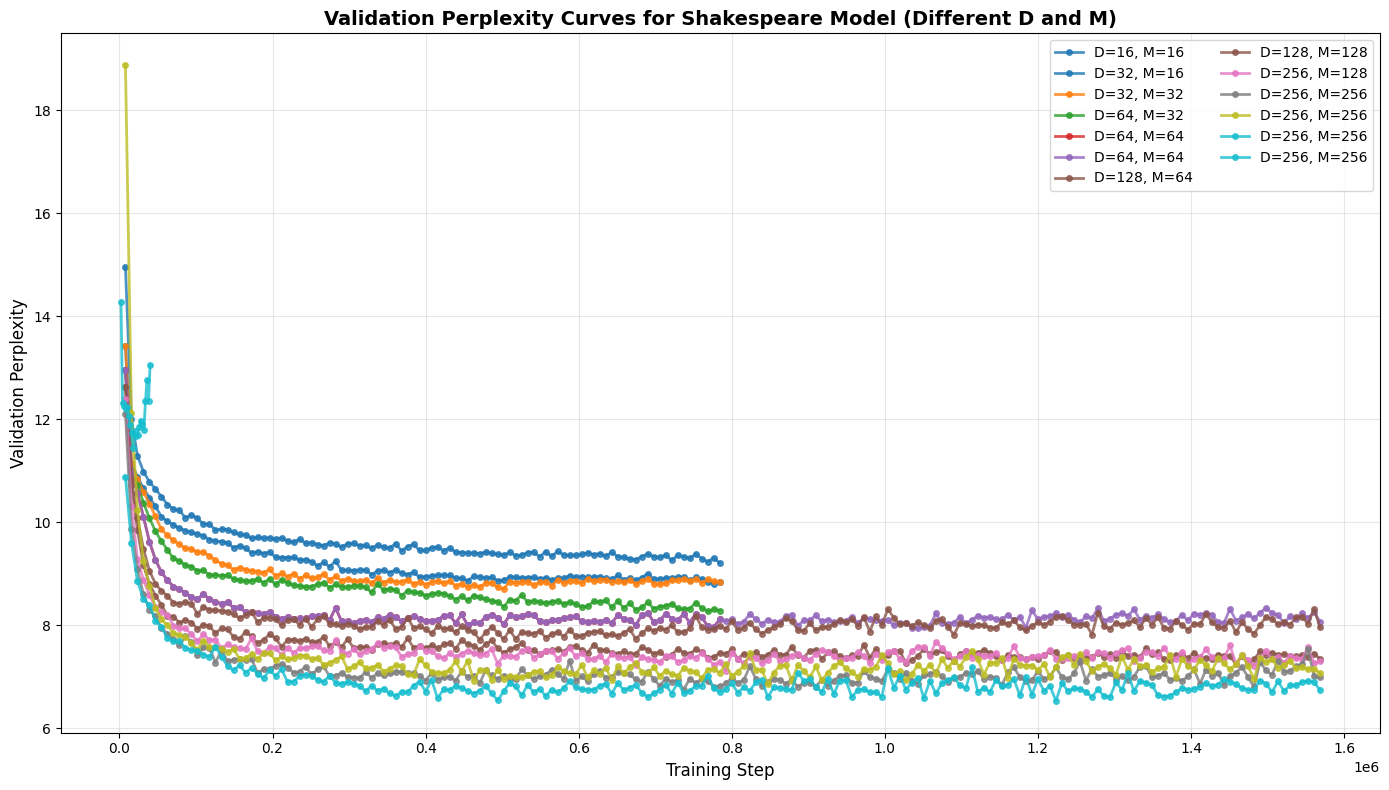

In [4]:
# Plot 2: Validation Perplexity Curves
fig, ax = plt.subplots(figsize=(14, 8))

for i, run in enumerate(runs):
    if run['perplexities'] is not None:
        steps = np.array(run['perplexities']['step'])
        perplexity = np.array(run['perplexities']['perplexity'])
        
        label = f"D={run['D']}, M={run['M']}"
        ax.plot(steps, perplexity, label=label, color=colors[i], linewidth=2, alpha=0.8, marker='o', markersize=4)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Validation Perplexity', fontsize=12)
ax.set_title('Validation Perplexity Curves for Shakespeare Model (Different D and M)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

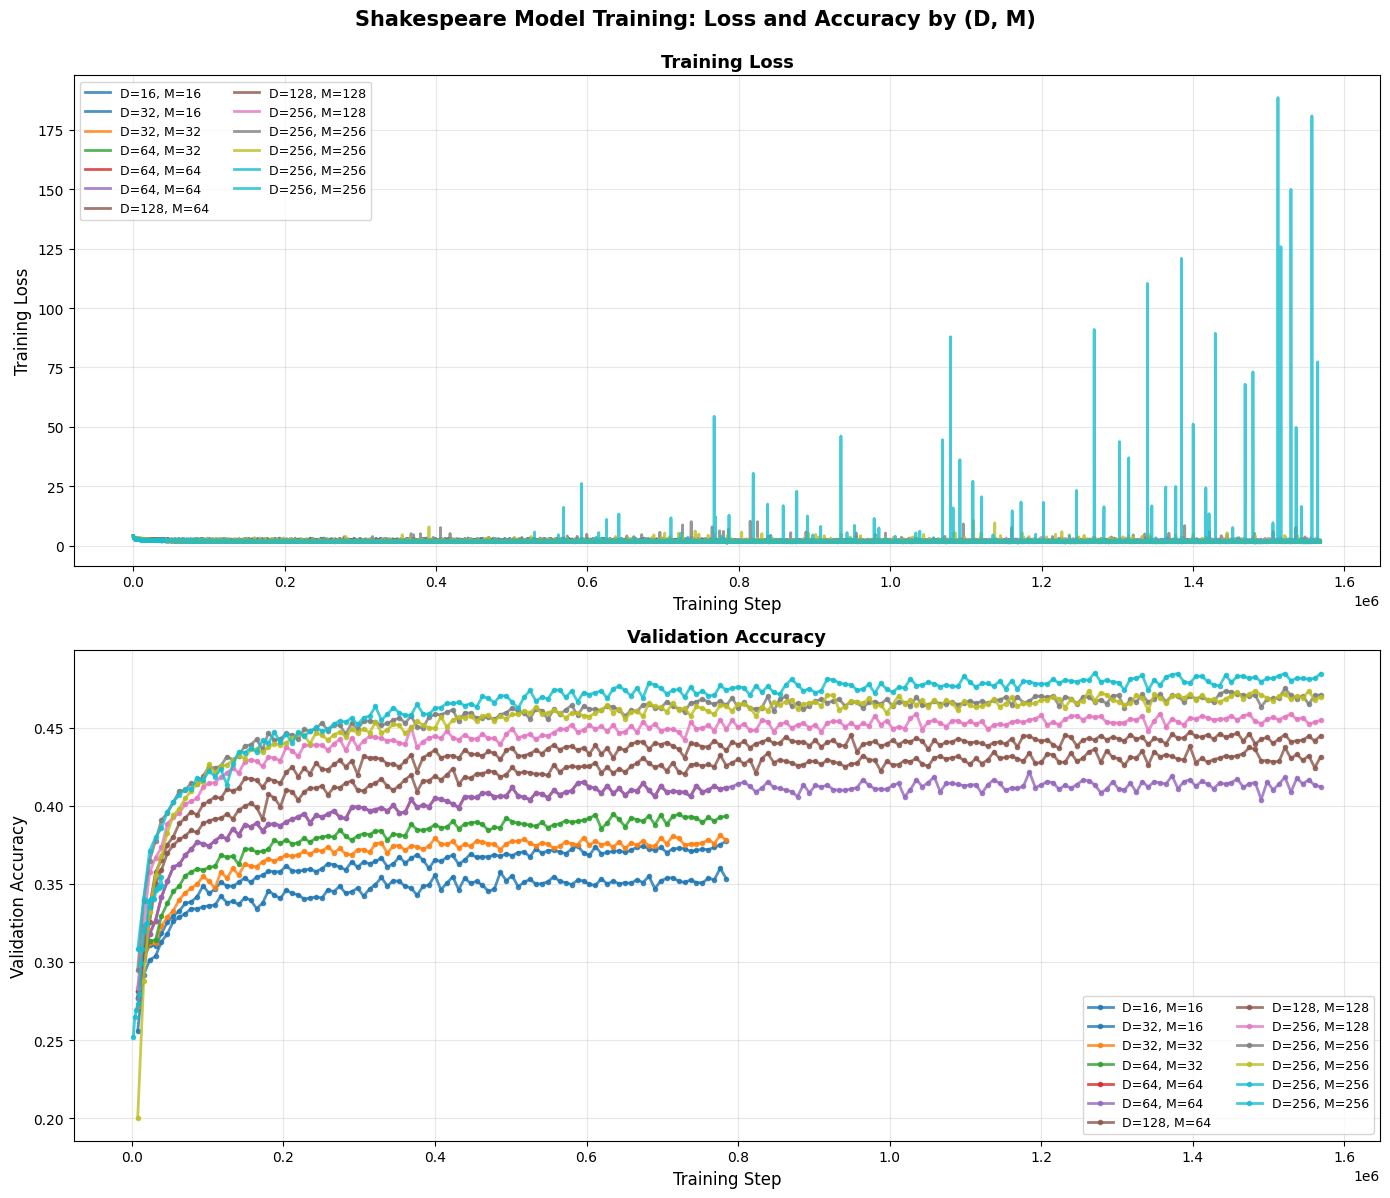

In [5]:
# Plot 3: Combined Training Loss and Validation Accuracy (subplots)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Training loss
for i, run in enumerate(runs):
    steps = np.array(run['losses']['step'])
    train_loss = np.array(run['losses']['loss'])
    label = f"D={run['D']}, M={run['M']}"
    axes[0].plot(steps, train_loss, label=label, color=colors[i], linewidth=2, alpha=0.8)

axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# Validation accuracy
for i, run in enumerate(runs):
    if run['accs'] is not None:
        steps = np.array(run['accs']['step'])
        accuracy = np.array(run['accs']['accuracy'])
        label = f"D={run['D']}, M={run['M']}"
        axes[1].plot(steps, accuracy, label=label, color=colors[i], linewidth=2, alpha=0.8, marker='o', markersize=3)

axes[1].set_xlabel('Training Step', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Shakespeare Model Training: Loss and Accuracy by (D, M)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

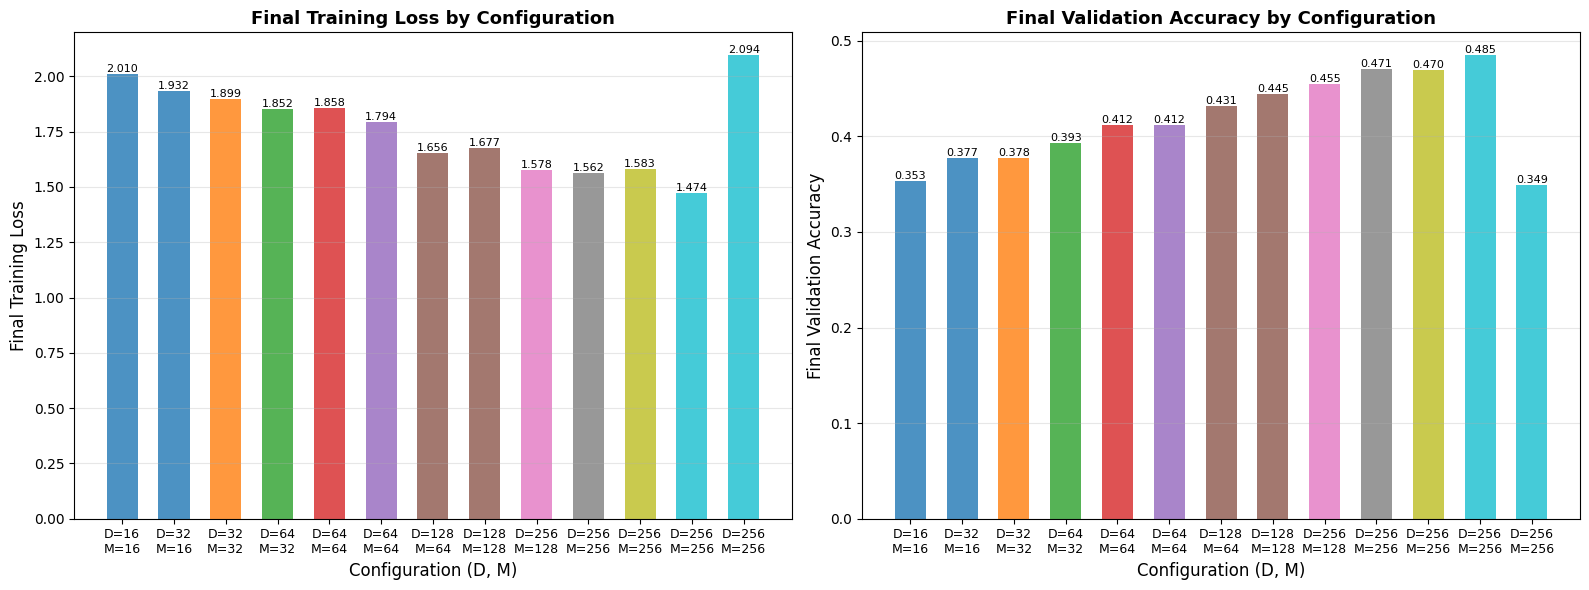

In [6]:
# Plot 4: Final Metrics Comparison (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract final metrics
D_values = [run['D'] for run in runs]
M_values = [run['M'] for run in runs]
labels = [f"D={run['D']}\nM={run['M']}" for run in runs]
final_train_loss = [run['losses']['loss'][-1] for run in runs]
final_accuracy = [run['accs']['accuracy'][-1] if run['accs'] is not None else 0 for run in runs]

x = np.arange(len(runs))
width = 0.6

# Training loss bar chart
bars1 = axes[0].bar(x, final_train_loss, width, color=colors, alpha=0.8)
axes[0].set_xlabel('Configuration (D, M)', fontsize=12)
axes[0].set_ylabel('Final Training Loss', fontsize=12)
axes[0].set_title('Final Training Loss by Configuration', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# Validation accuracy bar chart
bars2 = axes[1].bar(x, final_accuracy, width, color=colors, alpha=0.8)
axes[1].set_xlabel('Configuration (D, M)', fontsize=12)
axes[1].set_ylabel('Final Validation Accuracy', fontsize=12)
axes[1].set_title('Final Validation Accuracy by Configuration', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

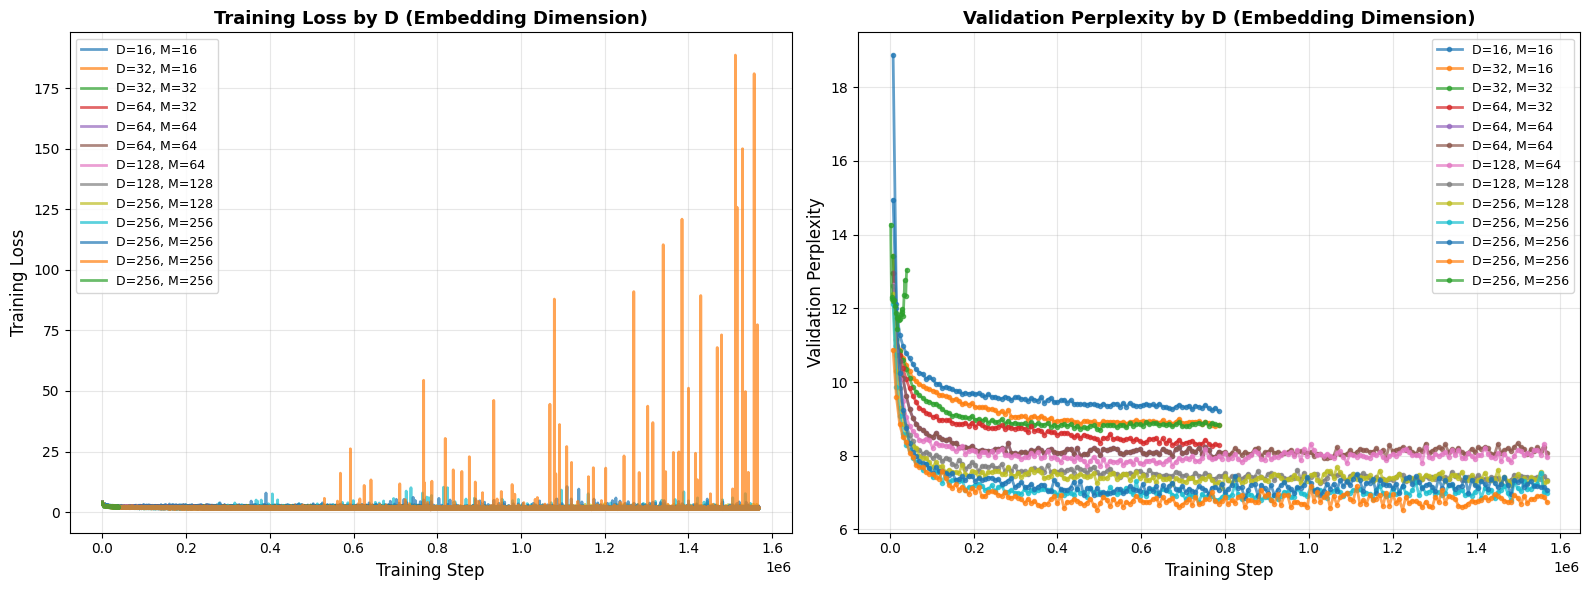

In [7]:
# Plot 5: Training Loss and Validation Perplexity by Model Size (D parameter)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Group by D value
D_to_runs = {}
for run in runs:
    D = run['D']
    if D not in D_to_runs:
        D_to_runs[D] = []
    D_to_runs[D].append(run)

unique_D = sorted(D_to_runs.keys())

# Plot training loss vs D
for D in unique_D:
    D_runs = D_to_runs[D]
    for run in D_runs:
        steps = np.array(run['losses']['step'])
        train_loss = np.array(run['losses']['loss'])
        label = f"D={run['D']}, M={run['M']}"
        axes[0].plot(steps, train_loss, label=label, linewidth=2, alpha=0.7)

axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss by D (Embedding Dimension)', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot validation perplexity vs D
for D in unique_D:
    D_runs = D_to_runs[D]
    for run in D_runs:
        if run['perplexities'] is not None:
            steps = np.array(run['perplexities']['step'])
            perplexity = np.array(run['perplexities']['perplexity'])
            label = f"D={run['D']}, M={run['M']}"
            axes[1].plot(steps, perplexity, label=label, linewidth=2, alpha=0.7, marker='o', markersize=3)

axes[1].set_xlabel('Training Step', fontsize=12)
axes[1].set_ylabel('Validation Perplexity', fontsize=12)
axes[1].set_title('Validation Perplexity by D (Embedding Dimension)', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Plot 6: Summary Statistics Table
print("=" * 100)
print("SUMMARY STATISTICS: Shakespeare Model Training Runs")
print("=" * 100)
print(f"{'Run':<20} {'D':<6} {'M':<6} {'Final Loss':<15} {'Final Acc':<15} {'Best Acc':<15} {'Final Perp':<15}")
print("-" * 100)

for run in runs:
    final_loss = run['losses']['loss'][-1]
    final_acc = run['accs']['accuracy'][-1] if run['accs'] is not None else 0
    best_acc = max(run['accs']['accuracy']) if run['accs'] is not None else 0
    final_perp = run['perplexities']['perplexity'][-1] if run['perplexities'] is not None else 0
    
    print(f"{run['name']:<20} {run['D']:<6} {run['M']:<6} {final_loss:<15.4f} {final_acc:<15.4f} {best_acc:<15.4f} {final_perp:<15.4f}")

print("=" * 100)

# Find best runs
best_loss_run = min(runs, key=lambda r: r['losses']['loss'][-1])
best_acc_run = max(runs, key=lambda r: r['accs']['accuracy'][-1] if r['accs'] is not None else 0)
best_perp_run = min(runs, key=lambda r: r['perplexities']['perplexity'][-1] if r['perplexities'] is not None else float('inf'))

print(f"\nBest Final Training Loss: D={best_loss_run['D']}, M={best_loss_run['M']} (Loss: {best_loss_run['losses']['loss'][-1]:.4f})")
print(f"Best Final Validation Accuracy: D={best_acc_run['D']}, M={best_acc_run['M']} (Acc: {best_acc_run['accs']['accuracy'][-1]:.4f})")
print(f"Best Final Validation Perplexity: D={best_perp_run['D']}, M={best_perp_run['M']} (Perp: {best_perp_run['perplexities']['perplexity'][-1]:.4f})")
print("=" * 100)

SUMMARY STATISTICS: Shakespeare Model Training Runs
Run                  D      M      Final Loss      Final Acc       Best Acc        Final Perp     
----------------------------------------------------------------------------------------------------
20260202_231239      16     16     2.0095          0.3533          0.3600          9.2054         
20260202_232806      32     16     1.9323          0.3774          0.3774          8.8449         
20260202_234939      32     32     1.8990          0.3778          0.3810          8.8328         
20260203_001217      64     32     1.8519          0.3932          0.3947          8.2825         
20260203_004751      64     64     1.8584          0.4117          0.4151          8.1105         
20260203_191105      64     64     1.7939          0.4122          0.4217          8.0652         
20260203_203522      128    64     1.6556          0.4313          0.4381          7.9591         
20260204_000631      128    128    1.6767          0.44